### Final Pipeline

In [1]:
# Create Output Folders for Enhanced Images
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

input_folder = "../frames/selected"
output_folder = "../frames/enhanced"

folders = ["1_Grayscale", "2_NoiseReduced", "3_IlluminationCorrected","4_FinalEnhanced"]

# Create main folder
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Create subfolders
for folder in folders:
    path = os.path.join(output_folder, folder)
    if not os.path.exists(path):
        os.makedirs(path)

print("All folders created!")

NameError: name 'output_folder' is not defined

In [18]:
# Convert images to grayscale and save in the folder

# Loop through all selected images
for file in os.listdir(input_folder):
    if file.endswith((".jpg", ".png", ".jpeg")):
        img = cv2.imread(os.path.join(input_folder, file))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        cv2.imwrite(os.path.join(output_folder, "1_Grayscale", file), gray)

print("Grayscale conversion completed!")

Grayscale conversion completed!


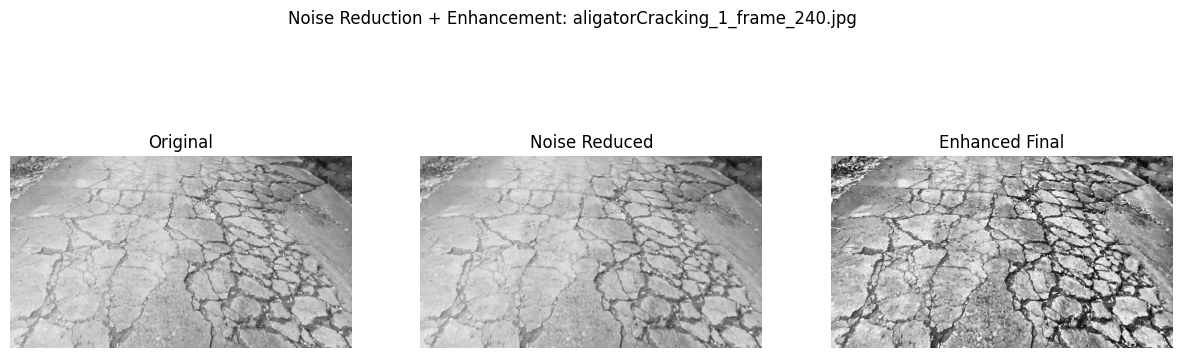

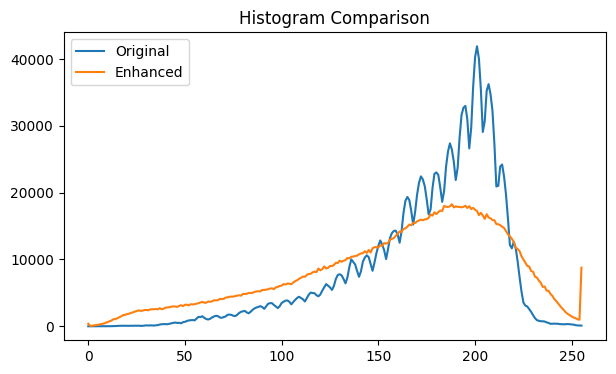

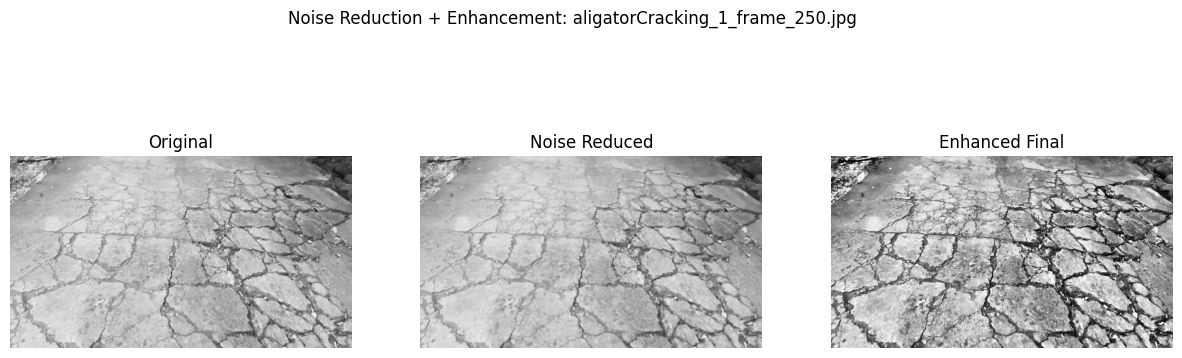

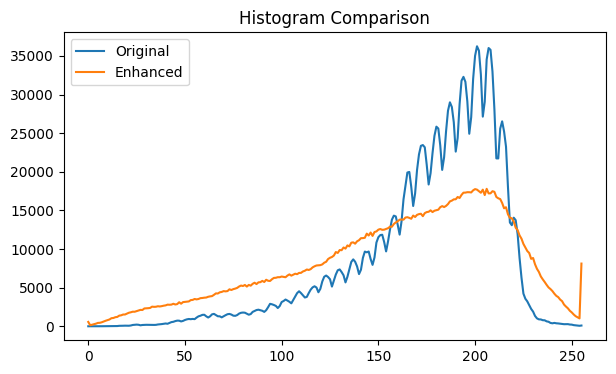

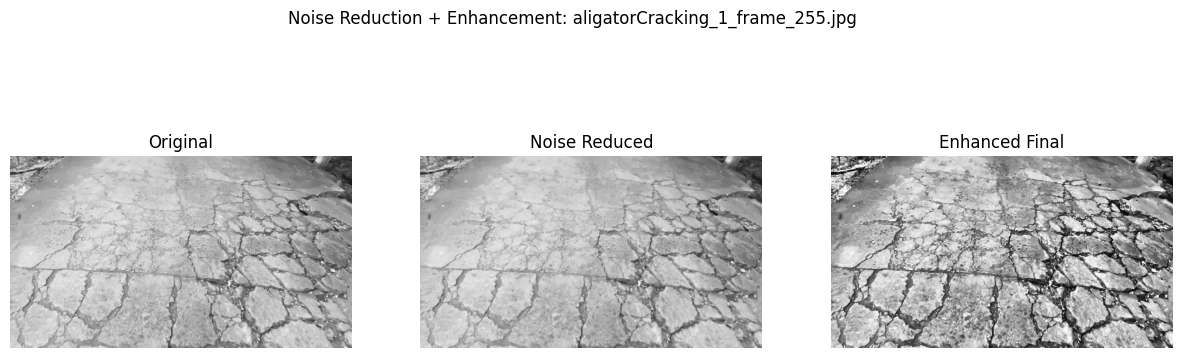

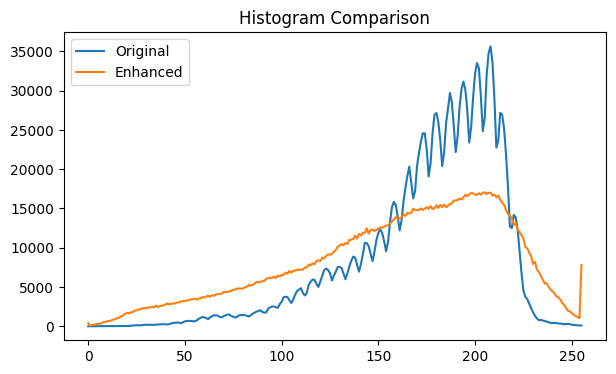

Noise reduction and enhancement completed.


In [19]:
# Noise Reduction + Enhancement

frames_folder = "../frames/enhanced/1_Grayscale"
output_folder = "../frames/enhanced/2_NoiseReduced"

os.makedirs(output_folder, exist_ok=True)

# Process only few images for analysis
max_images = 3
count = 0

for file in os.listdir(frames_folder):

    if not file.endswith((".jpg", ".png", ".jpeg")):
        continue

    path = os.path.join(frames_folder, file)

    img = cv2.imread(path)

    if img is None:
        continue

    # ---------------- STEP 1 : MEDIAN FILTER ----------------
    # Removes small asphalt noise while preserving crack lines
    median = cv2.medianBlur(img, 3)

    # ---------------- STEP 2 : GAUSSIAN FILTER ----------------
    # Smooths image noise
    denoised = cv2.GaussianBlur(median, (5,5), 0)

    # ---------------- STEP 3 : CLAHE CONTRAST ENHANCEMENT ----------------
    # Improves local crack visibility
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)
    enhanced = clahe.apply(gray)

    # ---------------- STEP 4 : LIGHT SHARPENING ----------------
    # Makes crack edges clearer for segmentation
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])

    sharpened = cv2.filter2D(enhanced, -1, kernel)

    # Save final enhanced image
    cv2.imwrite(os.path.join(output_folder, file), sharpened)

    # ---------------- VISUAL ANALYSIS ----------------
    if count < max_images:

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.imshow(img, cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(denoised, cmap="gray")
        plt.title("Noise Reduced")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(sharpened, cmap="gray")
        plt.title("Enhanced Final")
        plt.axis("off")

        plt.suptitle(f"Noise Reduction + Enhancement: {file}")
        plt.show()

        # Histogram Comparison
        plt.figure(figsize=(7,4))

        hist1 = cv2.calcHist([img],[0],None,[256],[0,256])
        hist2 = cv2.calcHist([sharpened],[0],None,[256],[0,256])

        plt.plot(hist1, label="Original")
        plt.plot(hist2, label="Enhanced")

        plt.title("Histogram Comparison")
        plt.legend()
        plt.show()

        count += 1

print("Noise reduction and enhancement completed.")

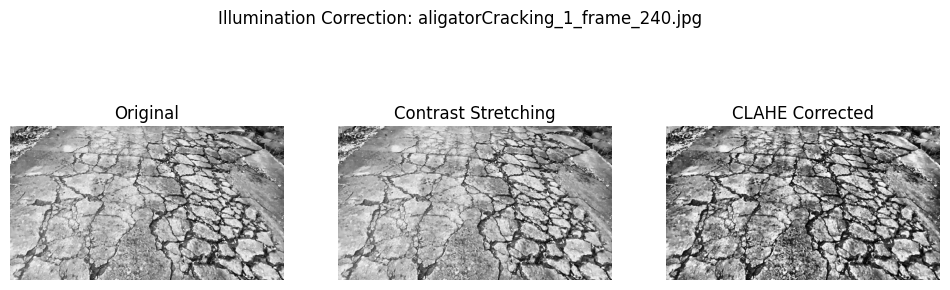

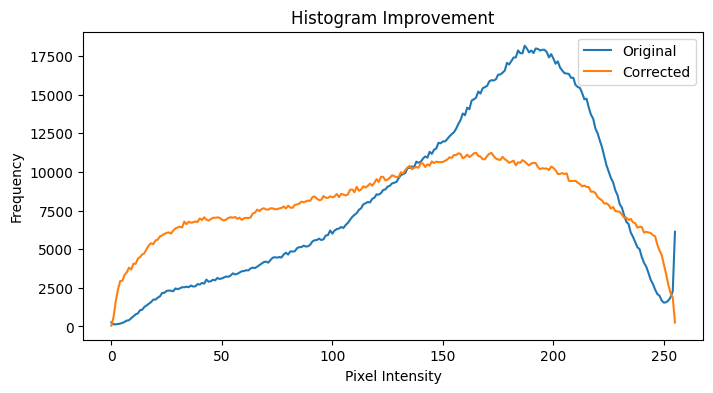

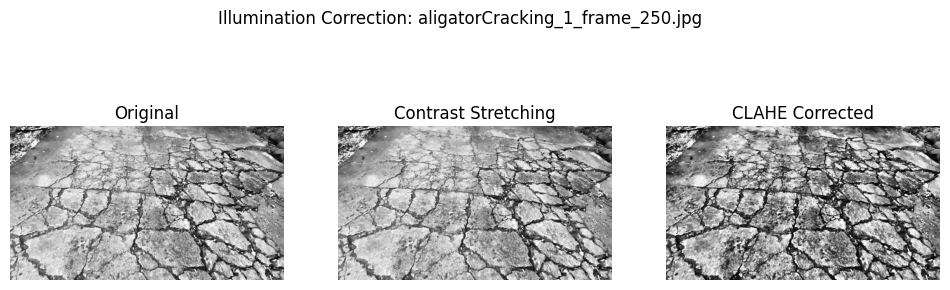

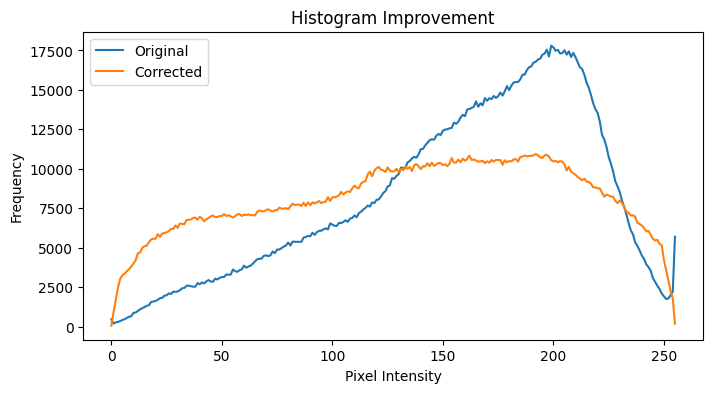

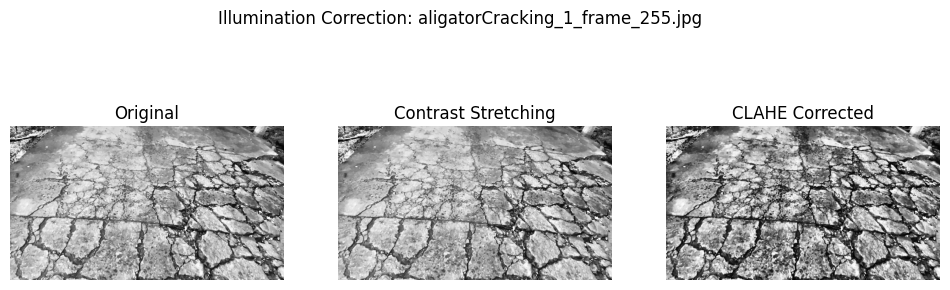

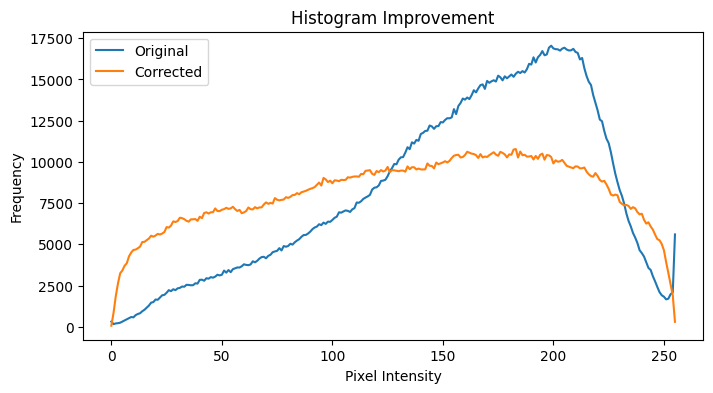

Illumination correction completed!


In [20]:
# Illumination Correction

input_folder = "../frames/enhanced/2_NoiseReduced"
output_folder = "../frames/enhanced/3_IlluminationCorrected"

os.makedirs(output_folder, exist_ok=True)

max_images = 3
count = 0

# Contrast Stretching function
def contrast_stretch(img):

    min_val = np.min(img)
    max_val = np.max(img)

    # Avoid division crash
    if max_val - min_val == 0:
        return img.copy()

    stretched = (img - min_val) * (255 / (max_val - min_val))

    return np.clip(stretched, 0, 255).astype(np.uint8)


for file in os.listdir(input_folder):

    if file.endswith((".jpg", ".png", ".jpeg")):

        path = os.path.join(input_folder, file)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # ---------------- CONTRAST STRETCHING ---------------- #
        contrast_img = contrast_stretch(img)

        # ---------------- CLAHE (BETTER THAN HISTOGRAM EQUALIZATION) ---------------- #
        # Prevents over-enhancement of road texture

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        )

        illum_corrected = clahe.apply(contrast_img)

        # ---------------- LIGHT SMOOTHING ---------------- #
        # Small smoothing to reduce enhanced texture noise

        illum_corrected = cv2.GaussianBlur(
            illum_corrected,
            (3,3),
            0
        )

        # Save final image
        cv2.imwrite(
            os.path.join(output_folder, file),
            illum_corrected
        )

        # ---------------- VISUAL ANALYSIS ---------------- #

        if count < max_images:

            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.imshow(img, cmap="gray")
            plt.title("Original")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(contrast_img, cmap="gray")
            plt.title("Contrast Stretching")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(illum_corrected, cmap="gray")
            plt.title("CLAHE Corrected")
            plt.axis("off")

            plt.suptitle(f"Illumination Correction: {file}")
            plt.show()

            # Histogram Comparison
            plt.figure(figsize=(8,4))

            hist1 = cv2.calcHist([img],[0],None,[256],[0,256])
            hist2 = cv2.calcHist([illum_corrected],[0],None,[256],[0,256])

            plt.plot(hist1, label="Original")
            plt.plot(hist2, label="Corrected")

            plt.title("Histogram Improvement")
            plt.xlabel("Pixel Intensity")
            plt.ylabel("Frequency")

            plt.legend()
            plt.show()

            count += 1

print("Illumination correction completed!")


Processing: aligatorCracking_1_frame_240.jpg
Before Sharpness: 213.8487904848452
Before Edge Strength: 100.59017317607021
Detected Type: Sharp
After Sharpness: 89.10235672842944
After Edge Strength: 91.50231772894364


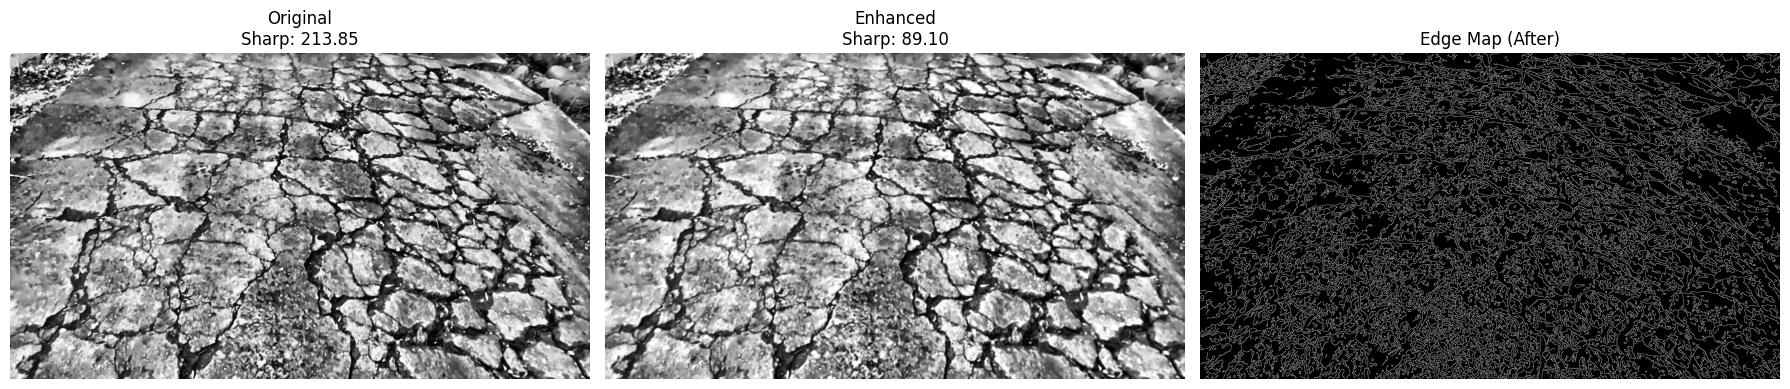


Processing: aligatorCracking_1_frame_250.jpg
Before Sharpness: 191.58059768303812
Before Edge Strength: 96.07704975305442
Detected Type: Sharp
After Sharpness: 80.40994158946687
After Edge Strength: 87.74981959929254


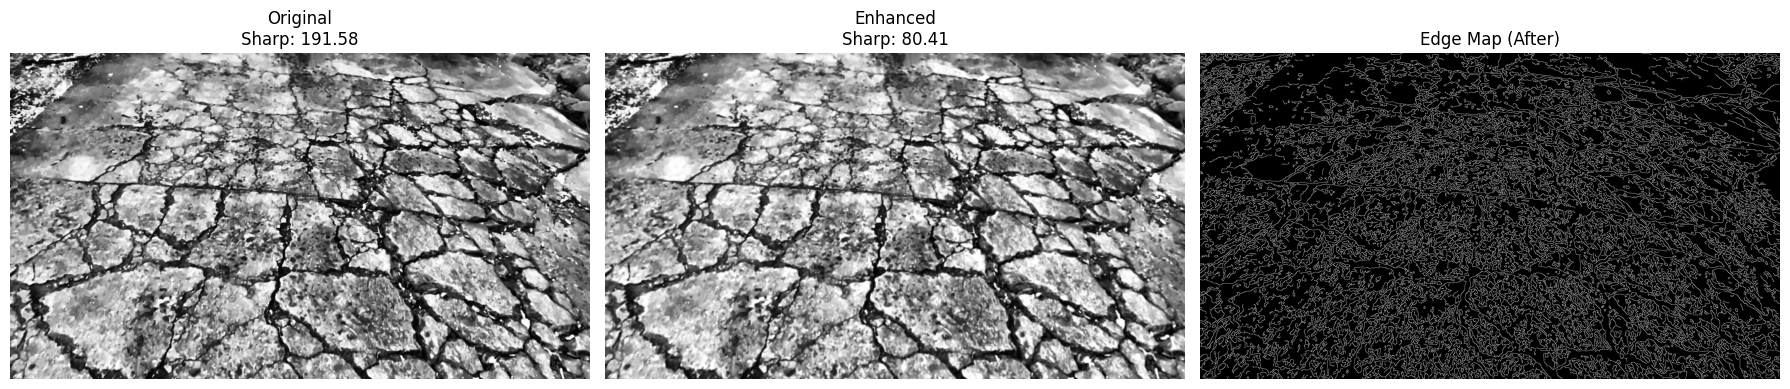


Processing: aligatorCracking_1_frame_255.jpg
Before Sharpness: 181.00623487287794
Before Edge Strength: 93.69718804327874
Detected Type: Sharp
After Sharpness: 76.64303069982752
After Edge Strength: 85.80697999095422


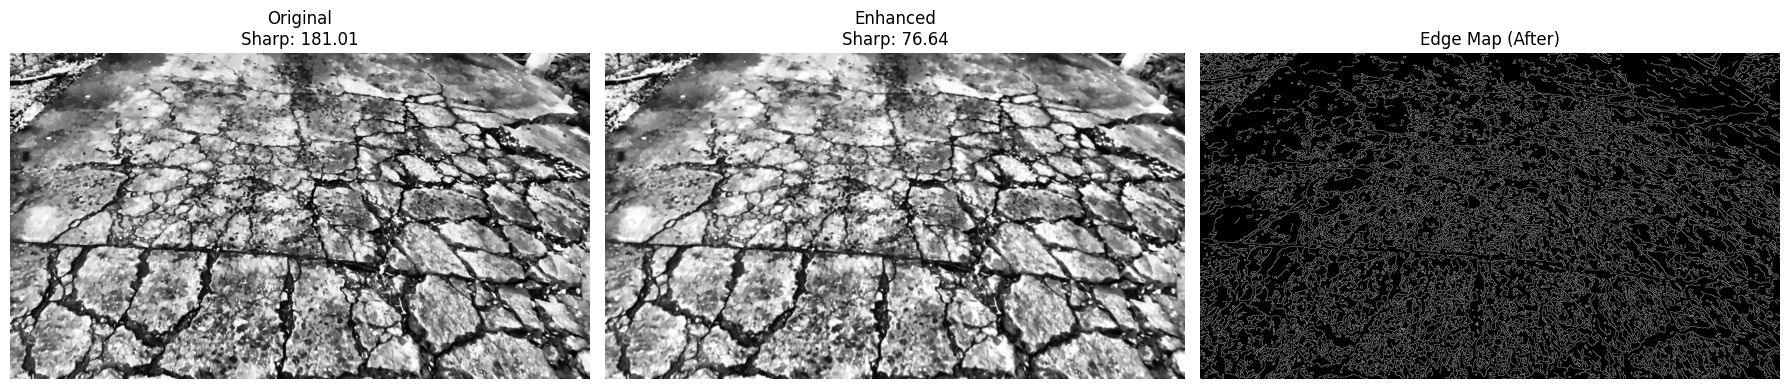


All images processed successfully!


In [8]:
# Motion blur and camera instability analysis

input_folder = "../frames/enhanced/3_IlluminationCorrected"
output_folder = "../frames/enhanced/4_FinalEnhanced"

os.makedirs(output_folder, exist_ok=True)

# ---------------- CREATE CATEGORY FOLDERS ---------------- #

categories = [
    "AligatorCracking",
    "TransverseCracking",
    "Pothole",
    "Raveling"
]

for category in categories:

    os.makedirs(
        os.path.join(output_folder, category),
        exist_ok=True
    )

max_images = 3
count = 0


# Sharpness (Laplacian)
def calculate_sharpness(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(img, cv2.CV_64F).var()


# Edge Strength (Sobel)
def calculate_edge_strength(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(sobelx**2 + sobely**2)

    return np.mean(magnitude)


# Blur Detection
def detect_blur_type(sharpness, edge_strength):

    # Slightly adjusted thresholds for road images

    if sharpness < 50:
        return "Strong Blur"

    elif sharpness < 100:
        return "Moderate Blur"

    elif edge_strength < 20:
        return "Edge Loss"

    else:
        return "Sharp"


# Enhancement Methods
def enhance_image(img, blur_type):

    # ---------------- LIGHT EDGE-PRESERVING SMOOTHING ---------------- #
    # Better than strong Gaussian blur for crack preservation

    base = cv2.GaussianBlur(
        img,
        (3,3),
        0
    )

    # ---------------- STRONG BLUR ---------------- #

    if blur_type == "Strong Blur":

        # Gentle unsharp masking
        gaussian = cv2.GaussianBlur(base, (0,0), 2.0)

        enhanced = cv2.addWeighted(
            base,
            1.4,
            gaussian,
            -0.4,
            0
        )

    # ---------------- MODERATE BLUR ---------------- #

    elif blur_type == "Moderate Blur":

        gaussian = cv2.GaussianBlur(base, (0,0), 1.5)

        enhanced = cv2.addWeighted(
            base,
            1.3,
            gaussian,
            -0.3,
            0
        )

    # ---------------- EDGE LOSS ---------------- #

    elif blur_type == "Edge Loss":

        # Mild sharpening only
        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])

        enhanced = cv2.filter2D(base, -1, kernel)

    # ---------------- SHARP ---------------- #

    else:

        # Keep natural appearance
        enhanced = cv2.convertScaleAbs(
            base,
            alpha=1.05,
            beta=0
        )

    # ---------------- FINAL SAFETY SMOOTHING ---------------- #
    # Prevents sharpening artifacts

    enhanced = cv2.GaussianBlur(enhanced, (3,3), 0)

    return enhanced


# Get images
image_files = []

for file in os.listdir(input_folder):

    if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        image_files.append(file)


# Process each image
for filename in image_files:

    path = os.path.join(input_folder, filename)

    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Failed to load:", filename)
        continue

    # Before
    sharp_before = calculate_sharpness(image)
    edge_before = calculate_edge_strength(image)

    # Classify
    blur_type = detect_blur_type(
        sharp_before,
        edge_before
    )

    # Enhance
    enhanced = enhance_image(image, blur_type)

    # After
    sharp_after = calculate_sharpness(enhanced)
    edge_after = calculate_edge_strength(enhanced)

    # ---------------- SELECT CATEGORY FOLDER ---------------- #

    if "aligator" in filename.lower():

        save_folder = "AligatorCracking"

    elif "transverse" in filename.lower():

        save_folder = "TransverseCracking"

    elif "pothole" in filename.lower():

        save_folder = "Pothole"

    elif "raveling" in filename.lower():

        save_folder = "Raveling"

    else:

        save_folder = ""

    # Save
    save_path = os.path.join(
        output_folder,
        save_folder,
        "enhanced_" + filename
    )

    cv2.imwrite(save_path, enhanced)

    # Visualization
    if count < max_images:

        print("\n==============================")
        print("Processing:", filename)

        print("Before Sharpness:", sharp_before)
        print("Before Edge Strength:", edge_before)

        print("Detected Type:", blur_type)

        print("After Sharpness:", sharp_after)
        print("After Edge Strength:", edge_after)

        edges_original = cv2.Canny(image, 50, 150)
        edges_enhanced = cv2.Canny(enhanced, 50, 150)

        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Original\nSharp: {sharp_before:.2f}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(enhanced, cmap='gray')
        plt.title(f"Enhanced\nSharp: {sharp_after:.2f}")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(edges_enhanced, cmap='gray')
        plt.title("Edge Map (After)")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        count += 1

print("\nAll images processed successfully!")